# P10: Exploratory sequence analysis

This is exploratory sequence analysis with no labels: the no-label first look you reach for *before* you have groups to compare. It is listed last in the catalog but used early, before any test-vs-reference contrast exists. When you have sequences but no labels yet, you can still describe what your sequences actually look like before any comparison: the per-position amino-acid composition (a **sequence logo**) and the per-position conservation (information content, in *bits*). This is *not* **determinant discovery** (CONTEXT.md), the test-vs-reference contrast that yields a **signature**. There is no contrast here at all: one pooled set, no test/reference split, no signature. We call this no-label first look *determinant-free profiling* as shorthand throughout (note: "profiling" is our informal label here, not a glossary term).

> **Key mental model: look before you label.** With no labels you cannot yet ask *what distinguishes my groups* (that is **determinant discovery**, see P1: CPP signature). But you *can* pool every sequence and ask two pre-questions: *where along the sequence does signal concentrate*, and *is there enough structure to make a comparison worth running*? A logo answers the first; conservation in bits answers the second.

A one-line decision rule: **Do you have labels? No, run exploratory profiling (this protocol). Yes, run CPP signature (P1).**

We work at the **domain level** (dataset prefix `DOM_`): the **unit of comparison** is the TMD-centric **part** set `jmd_n` / `tmd` / `jmd_c`, the native ground for CPP.

**When to use it.** Use this protocol when you have a set of sequences (one biological family, one screen, one organism) and want a first look *before* committing to any model or comparison. Typical questions:

- *Is my TMD region more conserved than its flanking JMDs?*
- *Is any single position dominated by one or a few residues?*
- *Are my sequences even structured enough to be worth profiling?*

**When not to use it.** Once you have two **labelled** sets and want to know *what physicochemically separates them*, skip ahead to **determinant discovery** via **CPP** (P1: CPP signature). A logo describes the **composition** of one pooled set; it does *not* contrast a **test group** (`label=1`) against a **reference group** (`label=0`), and it produces no **signature**.

**Input.** The input is a `df_seq` in **position-based** format: an `entry` column (unique protein id), a `sequence` column, and the `tmd_start` / `tmd_stop` boundaries (**1-based, start- and stop-inclusive**).

There is no upstream protocol: this is the no-label first look, listed last in the catalog but used before you have labels. Its input is whatever sequence table you bring; here we use a small bundled dataset. Note that a `label` column may be present (it is, in `DOM_GSEC`), but we **ignore it on purpose** (profiling is determinant-free).

In [1]:
import matplotlib.pyplot as plt
import aaanalysis as aa

aa.options["verbose"] = False

# DOM_GSEC at the domain level; n=25 per class -> 50 rows. We will NOT use df_seq["label"].
df_seq = aa.load_dataset(name="DOM_GSEC", n=25)
aa.display_df(df=df_seq[["entry", "sequence", "tmd_start", "tmd_stop"]], n_rows=5)

,entry,sequence,tmd_start,tmd_stop
1,Q14802,MQKVTLGLLVFLAGF...PGETPPLITPGSAQS,37,59
2,Q86UE4,MAARSWQDELAQQAE...SPKQIKKKKKARRET,50,72
3,Q969W9,MHRLMGVNSTAAAAA...AIWSKEKDKQKGHPL,41,63
4,P53801,MAPGVARGPTPYWRL...GLFKEENPYARFENN,97,119
5,Q8IUW5,MAPRALPGSAVLAAA...EVPATPVKRERSGTE,59,81


In [2]:
# Slice each sequence into the parts we profile.
# Request jmd_n, tmd, jmd_c so the logo spans the full JMD-N + TMD + JMD-C window.
sf = aa.SequenceFeature()
df_parts = sf.get_df_parts(
    df_seq=df_seq,
    list_parts=["jmd_n", "tmd", "jmd_c"],
    jmd_n_len=10,
    jmd_c_len=10,
)
aa.display_df(df=df_parts, n_rows=5)

,jmd_n,tmd,jmd_c
entry,,,
Q14802,NSPFYYDWHS,LQVGGLICAGVLCAMGIIIVMSA,KCKCKFGQKS
Q86UE4,LGLEPKRYPG,WVILVGTGALGLLLLFLLGYGWA,AACAGARKKR
Q969W9,FQSMEITELE,FVQIIIIVVVMMVMVVVITCLLS,HYKLSARSFI
P53801,RWGVCWVNFE,ALIITMSVVGGTLLLGIAICCCC,CCRRKRSRKP
Q8IUW5,NDTGNGHPEY,IAYALVPVFFIMGLFGVLICHLL,KKKGYRCTTE


**Run.** Behind the scenes, `AAlogo` aligns the variable-length TMDs to a fixed width (`tmd_len`) and tallies the per-position composition across **all** sequences (see the AAlogo examples for the function details). We pass **no `labels` argument**, so every sequence is pooled into a single profile: this is what makes the read-out determinant-free.

Two quantities come out:

- `get_df_logo`: a **composition** matrix (`probability` per amino acid, per position).
- `get_df_logo_info`: per-position **conservation** in bits (0 = uniform, ~4.32 = a single fully-conserved residue), which `get_conservation` collapses to a scalar.

Profiling is fully deterministic (every step is a pooled tally), so no `random_state` is needed here.

In [3]:
al = aa.AAlogo(logo_type="probability")

# deterministic: pooled tally over all sequences, no RNG -> random_state not applicable.
# tmd_len=20 aligns the variable-length TMDs to a fixed width:
# 10 (jmd_n) + 20 (tmd) + 10 (jmd_c) = 40 positions.
df_logo = al.get_df_logo(df_parts=df_parts, tmd_len=20)          # (40, 20) pooled composition
df_logo_info = al.get_df_logo_info(df_parts=df_parts, tmd_len=20)  # per-position bits, index "pos"

cons_mean = al.get_conservation(df_logo_info=df_logo_info, value_type="mean")
cons_max = al.get_conservation(df_logo_info=df_logo_info, value_type="max")
cons_mean, cons_max  # returned objects, no print()

(np.float64(1.0053701890712694), np.float64(1.7905267823848006))

**Output.** Three things flow out: the logo matrix `df_logo`, the per-position conservation series `df_logo_info`, and the scalar summaries above. The figure below is this protocol's gallery image: **letter height = composition** at that position, and the **gray overlay bar = conservation in bits**. Tall, single-letter stacks mark dominated positions; tall gray bars mark conserved ones.

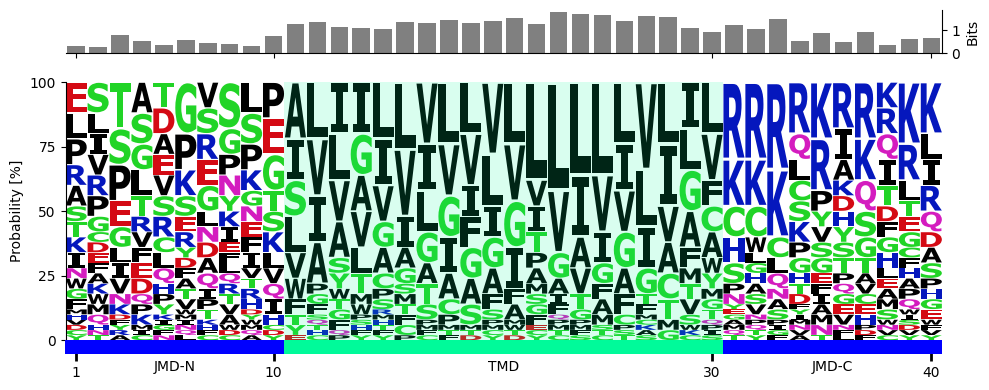

In [4]:
alp = aa.AAlogoPlot(logo_type="probability", jmd_n_len=10, jmd_c_len=10, verbose=False)
fig, ax = alp.single_logo(df_logo=df_logo, df_logo_info=df_logo_info, figsize=(10, 4))
plt.tight_layout()
plt.show()

**How to interpret.** A few things happened here. The colored letters trace **what** sits at each position: where the stack collapses onto one or two tall letters, that position is compositionally dominated. The gray bars trace **how conserved** each position is: with a TMD-centric set like this you will often see the gray bars rise over the membrane-spanning `tmd` and stay flatter over the `jmd_n` / `jmd_c` flanks, though on a small pooled set the per-position pattern can be noisy. That contrast is the whole point: when it appears, it tells you positional signal concentrates inside the TMD.

| Region | High bits there means ... |
|---|---|
| `jmd_n` / `jmd_c` (flanks) | the juxtamembrane context is constrained, not just variable linker |
| `tmd` (core) | the membrane span carries a conserved positional pattern, a candidate place to look once you have labels |

**Key takeaways**

- A logo reads **composition**; information content (bits) reads **conservation**: two different questions, one figure.
- Pooling every sequence is **determinant-free**: it *describes* one set, it does **not** *compare* groups.
- A position with high conservation is a candidate hotspot to revisit once you *do* have labels and can run a **test-vs-reference** comparison.

**Common mistakes.**

- **Feeding the default parts to the logo plot.** `SequenceFeature.get_df_parts` defaults to `tmd` / `jmd_n_tmd_n` / `tmd_c_jmd_c`; `AAlogo` then sees only the `tmd` column and you get a TMD-only logo. Pairing that with `AAlogoPlot(jmd_n_len=10, jmd_c_len=10)` raises a length error (the JMD lengths no longer fit the logo). Always request `list_parts=["jmd_n", "tmd", "jmd_c"]`.
- **Keeping the JMD lengths out of sync.** `AAlogoPlot(jmd_n_len, jmd_c_len)` must match the `jmd_n_len` / `jmd_c_len` you passed to `get_df_parts`.
- **Reading a logo as a discriminative result.** High conservation across the pooled set says *nothing* about test vs reference, that needs **CPP**. The logo is a one-set description, not a contrast.
- **Wrong unit for residue-level data.** For windowed / per-residue tasks (`AA_*`) you would first sample fixed-length **windows** with `AAWindowSampler`, then profile those: same *look-before-you-label* idea, different **unit of comparison** (a window instead of a part set).

**Next step.** Now that you have seen *where* positional signal lives, attach labels and ask what actually *separates* your groups.

Continue with **P1: CPP signature**, which picks up this same `df_parts` (still at the domain level), contrasts a **test group** (`label=1`) against a **reference group** (`label=0`), and reads out the **signature** of the test group.